<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab09/lab09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab09/lab09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question Answering — podejście klasyczne vs transformerowe
## Pipeline: PoQuAD → Baseline klasyczny (TF-IDF + retrieval) → Fine-tuning HerBERT → Porównanie

**Zadanie:** *Extractive Question Answering* — mając kontekst (fragment tekstu) oraz pytanie, model wskazuje w tekście **wycinek (span)**, który stanowi odpowiedź. To samo sformułowanie zadania co w oryginalnym SQuAD.

**Dataset:** [`clarin-pl/poquad`](https://huggingface.co/datasets/clarin-pl/poquad) — polski odpowiednik SQuAD 2.0 od CLARIN-PL. Zawiera ok. **52 tys. par pytanie–odpowiedź** z kontekstami z polskiej Wikipedii.

**Modele:**
- **Klasyczny baseline:** TF-IDF + dopasowanie zdania → wycinanie odpowiedzi heurystyką NER (spaCy).
- **Transformer:** `allegro/herbert-base-cased` — polski BERT od Allegro (ten sam, który trenowaliśmy w lab. 8 do klasyfikacji).


> **⚠️ Uwaga o środowisku:** Ten notatnik wymaga GPU do części transformerowej. Przed uruchomieniem zmień typ środowiska wykonawczego Colab: **Środowisko wykonawcze → Zmień typ środowiska wykonawczego → T4 GPU**. Na CPU fine-tuning trwałby wielokrotnie dłużej.


# 1. Instalacja i import bibliotek

Instalujemy pakiety Hugging Face oraz spaCy (używany w klasycznym baseline'ie do wyboru kandydatów na odpowiedź na podstawie typów encji).


In [78]:
# Instalacja pakietów (cicho, żeby nie zaśmiecać wyjścia)
!pip install -q transformers datasets accelerate evaluate
!pip install -q spacy
!python -m spacy download pl_core_news_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 82.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [79]:
# Weryfikacja dostępności GPU
import torch
print(f"CUDA dostępna: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Urządzenie: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ Brak GPU — fine-tuning będzie bardzo wolny!")


CUDA dostępna: True
Urządzenie: Tesla T4
VRAM: 15.6 GB


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    pipeline,
    DefaultDataCollator,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import re
import string
import collections
import random
from tqdm.auto import tqdm

# Ustalenie ziarna dla powtarzalności
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Wszystkie biblioteki załadowane pomyślnie ✓")


Wszystkie biblioteki załadowane pomyślnie ✓


# 2. Ładowanie datasetu PoQuAD

PoQuAD ma strukturę identyczną ze SQuAD, tzn. każdy rekord zawiera:
- `id` — identyfikator pytania,
- `title` — tytuł artykułu Wikipedii, z którego pochodzi kontekst,
- `context` — fragment tekstu (kilkaset–kilka tysięcy znaków),
- `question` — pytanie w języku polskim,
- `answers` — słownik z listami `text` (tekst odpowiedzi) i `answer_start` (pozycja znaku rozpoczynającego odpowiedź w `context`).


In [81]:
# Ładowanie datasetu z Hugging Face Hub
raw_datasets = load_dataset("clarin-pl/poquad", revision="refs/convert/parquet")

print("Struktura datasetu:")
print(raw_datasets)
print()
print("Przykładowy rekord (skrócony):")
ex = raw_datasets['train'][0]
print(f"  id:       {ex['id']}")
print(f"  title:    {ex['title']}")
print(f"  question: {ex['question']}")
print(f"  context:  {ex['context'][:200]}...")
print(f"  answers:  {ex['answers']}")


Struktura datasetu:
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 46187
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 5764
    })
})

Przykładowy rekord (skrócony):
  id:       1
  title:    Konfederacja polsko-czechosłowacka
  question: Co było powodem powrócenia konceptu porozumieniu monachijskiego?
  context:  Projekty konfederacji zaczęły się załamywać 5 sierpnia 1942. Ponownie wróciła kwestia monachijska, co uaktywniło się wymianą listów Ripka – Stroński. Natomiast 17 sierpnia 1942 doszło do spotkania E. ...
  answers:  {'text': ['wymianą listów Ripka – Stroński'], 'answer_start': [117]}


## 2.1. Statystyki datasetu

Sprawdźmy długości kontekstów, pytań i odpowiedzi — to pomoże nam później dobrać `max_length` dla tokenizera.


In [82]:
# Rozkład długości w znakach (szybkie podsumowanie)
df_stats = pd.DataFrame({
    'len_context_chars':  [len(x) for x in raw_datasets['train']['context']],
    'len_question_chars': [len(x) for x in raw_datasets['train']['question']],
    'len_answer_chars':   [len(a['text'][0]) if a['text'] else 0 for a in raw_datasets['train']['answers']],
})

print("Statystyki długości (w znakach) — zbiór treningowy:")
print(df_stats.describe().round(1).to_string())


Statystyki długości (w znakach) — zbiór treningowy:
       len_context_chars  len_question_chars  len_answer_chars
count            46187.0             46187.0           46187.0
mean               919.3                59.2              42.1
std                442.3                21.1              48.1
min                487.0                 9.0               1.0
25%                620.0                44.0              12.0
50%                788.0                56.0              25.0
75%               1068.0                71.0              56.0
max               8082.0               212.0            1142.0


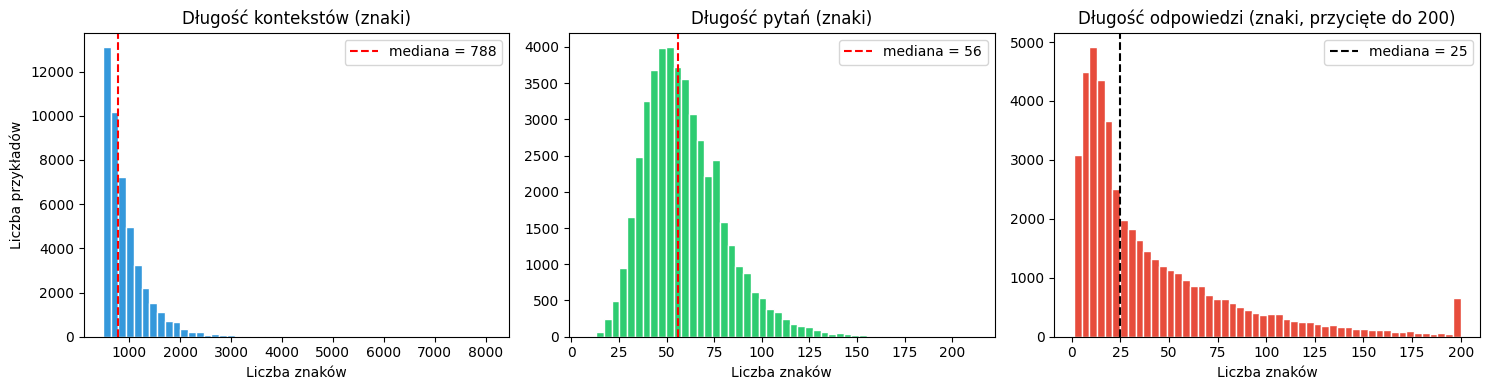

In [83]:
# Wizualizacja rozkładów
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_stats['len_context_chars'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Długość kontekstów (znaki)')
axes[0].set_xlabel('Liczba znaków')
axes[0].set_ylabel('Liczba przykładów')
axes[0].axvline(df_stats['len_context_chars'].median(), color='red', linestyle='--', label=f'mediana = {df_stats["len_context_chars"].median():.0f}')
axes[0].legend()

axes[1].hist(df_stats['len_question_chars'], bins=50, color='#2ecc71', edgecolor='white')
axes[1].set_title('Długość pytań (znaki)')
axes[1].set_xlabel('Liczba znaków')
axes[1].axvline(df_stats['len_question_chars'].median(), color='red', linestyle='--', label=f'mediana = {df_stats["len_question_chars"].median():.0f}')
axes[1].legend()

axes[2].hist(df_stats['len_answer_chars'].clip(upper=200), bins=50, color='#e74c3c', edgecolor='white')
axes[2].set_title('Długość odpowiedzi (znaki, przycięte do 200)')
axes[2].set_xlabel('Liczba znaków')
axes[2].axvline(df_stats['len_answer_chars'].median(), color='black', linestyle='--', label=f'mediana = {df_stats["len_answer_chars"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()


**Wnioski:**
- Konteksty są **długie** (mediana ~1000 znaków, maks. >8000) — wymusi to tokenizację z przesuwnym oknem (stride).
- Pytania są krótkie (~50–70 znaków, zwykle <150 znaków).
- Odpowiedzi są bardzo krótkie (mediana ~10–30 znaków) — typowo to pojedyncza fraza lub kilka słów.


# 3. Metryki ewaluacji QA — Exact Match i F1

Odpowiedź złota (ang. gold answer, gold standard) to w zadaniach Question Answering poprawna, wzorcowa odpowiedź pochodząca z datasetu — ta, którą człowiek oznaczył jako prawidłową podczas tworzenia zbioru. Jest to "prawda wzorcowa" (ground truth), z którą porównujemy predykcję modelu.

Oficjalny benchmark SQuAD używa dwóch metryk:

1. **Exact Match (EM)** — binarne: odpowiedź modelu musi być **dokładnie taka sama** jak odpowiedź złota (po normalizacji: usunięciu interpunkcji, rodzajników, wielkich liter, nadmiarowych białych znaków).
2. **F1 (token-level)** — traktuje odpowiedź jako zbiór tokenów i liczy F1 między tokenami predykcji a tokenami odpowiedzi złotej. Pozwala na **częściowe trafienie** (np. modelowa „Jan Kowalski" vs złota „Kowalski" → F1 = 0.67).

Implementujemy uproszczoną wersję funkcji normalizującej tekst i metryk — jak w oryginalnym kodzie SQuAD, ale dostosowaną do polskiego.


In [84]:
def normalize_answer(s):
    """Normalizacja odpowiedzi w stylu SQuAD: małe litery, usunięcie interpunkcji i nadmiarowych spacji."""
    def remove_punc(text):
        # Zachowujemy polskie znaki diakrytyczne
        # Dodatkowe znaki interpunkcyjne spoza string.punctuation (typograficzne dla polskiego)
        extra = '\u2013\u2014\u201e\u201d\u201c\u2018\u2019'  # – — „ " " ' '
        exclude = set(string.punctuation + extra)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    def white_space_fix(text):
        return ' '.join(text.split())

    return white_space_fix(remove_punc(lower(s)))


def get_tokens(s):
    """Tokenizacja na potrzeby metryki F1 — prosty split po białych znakach po normalizacji."""
    if not s:
        return []
    return normalize_answer(s).split()


def compute_exact(a_gold, a_pred):
    return int(normalize_answer(a_gold) == normalize_answer(a_pred))


def compute_f1(a_gold, a_pred):
    gold_toks = get_tokens(a_gold)
    pred_toks = get_tokens(a_pred)
    common = collections.Counter(gold_toks) & collections.Counter(pred_toks)
    num_same = sum(common.values())
    if len(gold_toks) == 0 or len(pred_toks) == 0:
        # Jeśli obie puste — trafienie; jeśli tylko jedna pusta — miss.
        return int(gold_toks == pred_toks)
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_toks)
    recall    = num_same / len(gold_toks)
    return 2 * precision * recall / (precision + recall)


def squad_metrics(predictions, references):
    """
    predictions: lista stringów (odpowiedzi modelu)
    references:  lista list stringów (każdy przykład może mieć >1 poprawną odpowiedź)
    Zwraca uśrednione EM i F1.
    """
    ems, f1s = [], []
    for pred, golds in zip(predictions, references):
        if not golds:  # brak złotej odpowiedzi — pomiń
            continue
        em = max(compute_exact(g, pred) for g in golds)
        f1 = max(compute_f1(g, pred)    for g in golds)
        ems.append(em)
        f1s.append(f1)
    return {
        'exact_match': 100.0 * np.mean(ems),
        'f1':          100.0 * np.mean(f1s),
        'n':           len(ems),
    }


# Szybki test poprawności
print("Test metryk:")
print(f"  EM('Jan Kowalski', 'jan kowalski') = {compute_exact('Jan Kowalski', 'jan kowalski')}")
print(f"  EM('Jan Kowalski', 'Kowalski')     = {compute_exact('Jan Kowalski', 'Kowalski')}")
print(f"  F1('Jan Kowalski', 'Kowalski')     = {compute_f1('Jan Kowalski', 'Kowalski'):.2f}")
print(f"  F1('1957 rok', 'w 1957')           = {compute_f1('1957 rok', 'w 1957'):.2f}")


Test metryk:
  EM('Jan Kowalski', 'jan kowalski') = 1
  EM('Jan Kowalski', 'Kowalski')     = 0
  F1('Jan Kowalski', 'Kowalski')     = 0.67
  F1('1957 rok', 'w 1957')           = 0.50


# 4. Baseline klasyczny — TF-IDF + heurystyki

Przed skomplikowanym fine-tuningiem warto mieć **prosty punkt odniesienia**. Klasyczna pipeline dla extractive QA bez sieci neuronowych:

1. **Wybór zdania:** Podziel kontekst na zdania. Policz podobieństwo TF-IDF między każdym zdaniem a pytaniem. Weź zdanie o największym podobieństwie — prawdopodobnie zawiera odpowiedź.
2. **Wyciągnięcie odpowiedzi:** W wybranym zdaniu zastosuj **typ pytania** (np. „Kiedy?" → szukaj daty, „Kto?" → szukaj osoby) i zwróć pasującą encję.
3. **Fallback:** Jeśli nic nie pasuje — zwróć całe najlepsze zdanie.

To podejście działa zaskakująco nieźle na łatwych pytaniach faktograficznych, ale zawodzi przy długich odpowiedziach lub złożonych relacjach.


In [85]:
import spacy

# Polski model spaCy (zainstalowany wyżej)
nlp = spacy.load("pl_core_news_sm")

# Heurystyka: pierwsze słowo pytania → oczekiwany typ odpowiedzi → etykieta NER spaCy
QUESTION_TYPE_TO_NER = {
    'kto':    {'persName', 'PER', 'PERSON'},
    'kogo':   {'persName', 'PER', 'PERSON'},
    'komu':   {'persName', 'PER', 'PERSON'},
    'kiedy':  {'date', 'DATE', 'time', 'TIME'},
    'gdzie':  {'placeName', 'geogName', 'LOC', 'GPE'},
    'dokąd':  {'placeName', 'geogName', 'LOC', 'GPE'},
    'skąd':   {'placeName', 'geogName', 'LOC', 'GPE'},
    'ile':    {'CARDINAL', 'QUANTITY', 'MONEY', 'PERCENT'},
    'w którym roku': {'date', 'DATE'},
    'którego roku':  {'date', 'DATE'},
}


def question_type(question):
    """Zwraca zbiór etykiet NER pasujących do typu pytania (lub None)."""
    q = question.lower().strip()
    # Najpierw spróbuj dopasowań wielowyrazowych
    for prefix, labels in QUESTION_TYPE_TO_NER.items():
        if ' ' in prefix and prefix in q:
            return labels
    # Potem pojedyncze słowa
    first = q.split()[0] if q.split() else ''
    first = first.rstrip('?')
    return QUESTION_TYPE_TO_NER.get(first)


def split_into_sentences(text):
    """Prosty podział na zdania (kropka/znak zapytania/wykrzyknik + spacja + duża litera)."""
    # Podział na granicach zdań, zachowujemy znaki końcowe
    sents = re.split(r'(?<=[.!?])\s+(?=[A-ZŁŻŚĆŃÓĄĘŹA-Ź])', text)
    return [s.strip() for s in sents if s.strip()]


def classical_qa(question, context):
    """Zwraca (odpowiedź_tekst, zdanie_źródłowe)."""
    sents = split_into_sentences(context)
    if not sents:
        return context[:50], context

    # 1. TF-IDF: znajdź zdanie najbardziej podobne do pytania
    try:
        vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
        tfidf = vectorizer.fit_transform(sents + [question])
        sims = cosine_similarity(tfidf[-1], tfidf[:-1]).flatten()
        best_idx = int(np.argmax(sims))
    except ValueError:
        best_idx = 0

    best_sentence = sents[best_idx]

    # 2. Wyciągnij kandydata na podstawie typu pytania
    expected_labels = question_type(question)
    if expected_labels:
        doc = nlp(best_sentence)
        candidates = [ent.text for ent in doc.ents if ent.label_ in expected_labels]
        if candidates:
            return candidates[0], best_sentence

    # 3. Fallback — zwróć całe zdanie (obcięte do rozsądnej długości)
    return best_sentence[:150], best_sentence


# Szybki test
ex = raw_datasets['validation'][234]
pred, src = classical_qa(ex['question'], ex['context'])
print(f"Pytanie:   {ex['question']}")
print(f"Złota:     {ex['answers']['text'][0] if ex['answers']['text'] else '(brak)'}")
print(f"Predykcja: {pred}")
print(f"Źródło:    {src[:150]}...")


Pytanie:   Jakie wiadomości publikuje troll?
Złota:     takich wiadomości jako przynęty, która – zdaniem trolla – potencjalnie mogłaby doprowadzić do wywołania dyskusji
Predykcja: Podstawą tego działania jest upublicznianie takich wiadomości jako przynęty, która – zdaniem trolla – potencjalnie mogłaby doprowadzić do wywołania dy
Źródło:    Podstawą tego działania jest upublicznianie takich wiadomości jako przynęty, która – zdaniem trolla – potencjalnie mogłaby doprowadzić do wywołania dy...


## 4.1. Ewaluacja klasycznego baseline'u

Ponieważ dataset nie udostępnia publicznego zbioru `test`, używamy `validation` jako zbioru ewaluacyjnego — taka konwencja jest standardem dla PoQuAD i innych zbiorów SQuAD-like.


In [86]:
# Ewaluacja na próbce walidacyjnej (pełne 5.7k byłoby zbyt wolne dla spaCy)
N_EVAL = 500
eval_subset = raw_datasets['validation'].shuffle(seed=SEED).select(range(N_EVAL))

classical_predictions = []
classical_references  = []

for ex in tqdm(eval_subset, desc="Klasyczny baseline"):
    pred, _ = classical_qa(ex['question'], ex['context'])
    classical_predictions.append(pred)
    classical_references.append(ex['answers']['text'])  # lista (zwykle 1 element)

classical_scores = squad_metrics(classical_predictions, classical_references)
print("\nWyniki klasycznego baseline'u (TF-IDF + NER spaCy):")
print(f"  Exact Match: {classical_scores['exact_match']:.2f}%")
print(f"  F1:          {classical_scores['f1']:.2f}")
print(f"  N przykładów: {classical_scores['n']}")


Klasyczny baseline:   0%|          | 0/500 [00:00<?, ?it/s]


Wyniki klasycznego baseline'u (TF-IDF + NER spaCy):
  Exact Match: 4.40%
  F1:          21.90
  N przykładów: 500


**Uwaga o wyniku klasycznego baseline'u:** Spodziewamy się **niskiego EM** (kilka–kilkanaście procent) oraz **F1 rzędu 20–30**. Główne przyczyny błędów:

- Pytania abstrakcyjne („Dlaczego…?", „W jaki sposób…?") nie mają typowej encji jako odpowiedzi.
- TF-IDF dopasowuje zdania po słowach kluczowych — nie rozumie relacji między faktami.
- Heurystyki NER tracą odpowiedzi krótsze lub dłuższe niż pojedyncza encja.

Transformer powinien radzić sobie znacznie lepiej, bo uczy się bezpośrednio zależności pytanie–kontekst.


# 5. Fine-tuning HerBERT — przygotowanie danych

Teraz budujemy pipeline transformerowy. Kluczowa różnica względem klasyfikacji z lab. 8 to **sposób tokenizacji**:

- Wejście do modelu to **para** `(pytanie, kontekst)` — łączone tokenem `[SEP]`.
- Kontekst bywa dłuższy niż `max_length` modelu → trzeba go pociąć na **okna z nakładką** (`doc_stride`).
- Model uczy się przewidywać dwie liczby dla każdego przykładu: **pozycję początku i końca odpowiedzi** w sekwencji tokenów.


In [87]:
MODEL_NAME = "allegro/herbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {type(tokenizer).__name__}")
print(f"Rozmiar słownika: {tokenizer.vocab_size}")
print(f"Specjalne tokeny: CLS={tokenizer.cls_token}, SEP={tokenizer.sep_token}")


Tokenizer: HerbertTokenizer
Rozmiar słownika: 50000
Specjalne tokeny: CLS=<s>, SEP=</s>


In [88]:
# Parametry tokenizacji
MAX_LENGTH = 384    # długość okna (pytanie + kawałek kontekstu)
DOC_STRIDE = 128    # nakładka między kolejnymi oknami tego samego kontekstu

# Szybki podgląd — ile tokenów zajmują typowe pytania i konteksty
sample = raw_datasets['train'].shuffle(seed=SEED).select(range(300))
q_lens = [len(tokenizer.tokenize(x)) for x in sample['question']]
c_lens = [len(tokenizer.tokenize(x)) for x in sample['context']]

print(f"Tokeny pytania  — mediana: {np.median(q_lens):.0f}, 95-percentyl: {np.percentile(q_lens, 95):.0f}")
print(f"Tokeny kontekstu — mediana: {np.median(c_lens):.0f}, 95-percentyl: {np.percentile(c_lens, 95):.0f}")
print(f"\nPrzy MAX_LENGTH = {MAX_LENGTH} i DOC_STRIDE = {DOC_STRIDE} każdy długi kontekst zostanie podzielony na kilka okien.")


Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


Tokeny pytania  — mediana: 12, 95-percentyl: 21
Tokeny kontekstu — mediana: 170, 95-percentyl: 369

Przy MAX_LENGTH = 384 i DOC_STRIDE = 128 każdy długi kontekst zostanie podzielony na kilka okien.


## 5.1. Przygotowanie danych treningowych — sliding window

Najtrudniejszy element całego pipeline'u. Dla każdego przykładu `(pytanie, kontekst, odpowiedź)`:

1. Tokenizujemy parę z opcjami `truncation="only_second"` (ucinamy tylko kontekst, nie pytanie) oraz `return_overflowing_tokens=True` (zwracamy wszystkie okna).
2. Dla każdego okna sprawdzamy, czy zawiera odpowiedź:
   - jeśli **tak** → oznaczamy `start_positions` i `end_positions` wskazujące pozycje tokenów początku/końca odpowiedzi,
   - jeśli **nie** → oznaczamy oba jako `0` (pozycja tokenu `[CLS]` — model uczy się, że „w tym oknie odpowiedzi nie ma").

Ten schemat pochodzi z [oficjalnego tutoriala HF dla QA](https://huggingface.co/learn/nlp-course/chapter7/7).


In [89]:
def prepare_train_features(examples):
    """Konwertuje przykłady PoQuAD na format wymagany przez model QA."""
    # Czasem w pytaniach są spacje na początku/końcu
    examples["question"] = [q.lstrip() for q in examples["question"]]

    # Tokenizacja — pytanie jako pierwsze, kontekst jako drugi
    tokenized = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=MAX_LENGTH,
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    # Po tokenizacji liczba wyjściowych okien >= liczba wejściowych przykładów
    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")

    tokenized["start_positions"] = []
    tokenized["end_positions"]   = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)

        # sequence_ids: 0 = pytanie, 1 = kontekst, None = specjalne
        sequence_ids = tokenized.sequence_ids(i)

        # Z którego oryginalnego przykładu pochodzi to okno
        sample_index = sample_mapping[i]
        answers = examples["answers"][sample_index]

        if len(answers["answer_start"]) == 0:
            # Przykład bez odpowiedzi — wskazujemy [CLS]
            tokenized["start_positions"].append(cls_index)
            tokenized["end_positions"].append(cls_index)
        else:
            start_char = answers["answer_start"][0]
            end_char   = start_char + len(answers["text"][0])

            # Znajdź indeks tokenu z początkiem kontekstu
            token_start_index = 0
            while sequence_ids[token_start_index] != 1:
                token_start_index += 1

            # Indeks tokenu z końcem kontekstu
            token_end_index = len(input_ids) - 1
            while sequence_ids[token_end_index] != 1:
                token_end_index -= 1

            # Jeśli odpowiedź jest poza oknem — oznacz [CLS]
            if not (offsets[token_start_index][0] <= start_char
                    and offsets[token_end_index][1] >= end_char):
                tokenized["start_positions"].append(cls_index)
                tokenized["end_positions"].append(cls_index)
            else:
                # Przesuwamy start_index w prawo, aż offsets[...][0] > start_char
                while (token_start_index < len(offsets)
                       and offsets[token_start_index][0] <= start_char):
                    token_start_index += 1
                tokenized["start_positions"].append(token_start_index - 1)

                # Przesuwamy end_index w lewo, aż offsets[...][1] < end_char
                while offsets[token_end_index][1] >= end_char:
                    token_end_index -= 1
                tokenized["end_positions"].append(token_end_index + 1)

    return tokenized


## 5.2. Przygotowanie podzbioru treningowego

Pełny zbiór treningowy (46k przykładów) na T4 dawałby ~40 min na epokę. Żeby zmieścić się w ~10 minutach, **losujemy podzbiór ~6000 przykładów** oraz trenujemy **2 epoki**. To wystarczy, żeby model nauczył się poprawnej struktury zadania i osiągnął sensowny wynik — nie będzie to SOTA, ale dydaktycznie pokażemy pełny pipeline i istotną przewagę nad klasycznym baseline'em.


In [90]:
# Ograniczenie zbioru treningowego dla szybkiego treningu na T4 (~10 min)
TRAIN_SIZE = 6000
EVAL_SIZE  = 1000

small_train = raw_datasets["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
small_eval  = raw_datasets["validation"].shuffle(seed=SEED).select(range(EVAL_SIZE))

print(f"Zbiór treningowy (podzbiór):   {len(small_train)} przykładów")
print(f"Zbiór walidacyjny (podzbiór):  {len(small_eval)} przykładów")


Zbiór treningowy (podzbiór):   6000 przykładów
Zbiór walidacyjny (podzbiór):  1000 przykładów


In [91]:
# Tokenizacja i przygotowanie pozycji odpowiedzi
train_features = small_train.map(
    prepare_train_features,
    batched=True,
    remove_columns=small_train.column_names,
    desc="Tokenizacja zbioru treningowego",
)

print(f"Po tokenizacji (sliding window): {len(train_features)} okien")
print(f"Średnio {len(train_features)/len(small_train):.2f} okna na przykład.")
print()
print("Przykładowe features:")
print({k: (v[:15] if isinstance(v, list) and len(v) > 15 else v)
       for k, v in train_features[0].items()})


Po tokenizacji (sliding window): 6387 okien
Średnio 1.06 okna na przykład.

Przykładowe features:
{'input_ids': [0, 46, 17513, 2399, 2972, 2012, 5668, 2289, 2517, 6580, 20559, 4125, 2041, 28576, 13262], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'start_positions': 29, 'end_positions': 34}


## 5.3. Przygotowanie danych walidacyjnych

Dla walidacji tokenizujemy analogicznie, ale zamiast `start_positions`/`end_positions` zachowujemy `offset_mapping` i `example_id` — są potrzebne do **post-processingu** (konwersji logitów na wycinki tekstu).


In [92]:
def prepare_validation_features(examples):
    """Tokenizacja zbioru walidacyjnego — zachowujemy offset_mapping do mapowania z powrotem na tekst."""
    examples["question"] = [q.lstrip() for q in examples["question"]]

    tokenized = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=MAX_LENGTH,
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")

    tokenized["example_id"] = []

    for i in range(len(tokenized["input_ids"])):
        sequence_ids = tokenized.sequence_ids(i)
        sample_index = sample_mapping[i]
        tokenized["example_id"].append(examples["id"][sample_index])

        # Dla tokenów nie pochodzących z kontekstu offset wyzerowujemy
        tokenized["offset_mapping"][i] = [
            (o if sequence_ids[k] == 1 else None)
            for k, o in enumerate(tokenized["offset_mapping"][i])
        ]

    return tokenized


validation_features = small_eval.map(
    prepare_validation_features,
    batched=True,
    remove_columns=small_eval.column_names,
    desc="Tokenizacja zbioru walidacyjnego",
)

print(f"Zbiór walidacyjny po tokenizacji: {len(validation_features)} okien")


Zbiór walidacyjny po tokenizacji: 1076 okien


# 6. Ładowanie modelu z głową QA

Model `AutoModelForQuestionAnswering` dokłada do pre-trenowanego HerBERT-a **głowę** — dwa niezależne klasyfikatory liniowe nad każdym tokenem:
- jeden przewiduje prawdopodobieństwo, że token jest **początkiem odpowiedzi**,
- drugi — że jest **końcem odpowiedzi**.

Głowa jest inicjalizowana losowo i trenujemy ją od zera (trzon modelu tylko dostrajamy).


In [93]:
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME)

# Liczba parametrów
n_params_total     = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Liczba parametrów (łącznie):     {n_params_total:,}")
print(f"Liczba parametrów (trenowanych): {n_params_trainable:,}")
print(f"Rozmiar na dysku: ~{n_params_total * 4 / 1e6:.0f} MB (float32)")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loa

Model: allegro/herbert-base-cased
Liczba parametrów (łącznie):     123,853,826
Liczba parametrów (trenowanych): 123,853,826
Rozmiar na dysku: ~495 MB (float32)


# 7. Konfiguracja treningu

Hiperparametry dobrane tak, aby trening zajął **ok. 10 minut na T4** i dał sensowne wyniki:

| Parametr | Wartość | Uzasadnienie |
|---|---|---|
| `learning_rate` | `3e-5` | Standard dla fine-tuningu BERT-like na QA |
| `num_train_epochs` | `2` | Kompromis między jakością a czasem |
| `per_device_train_batch_size` | `16` | Maksimum mieszczące się w VRAM T4 (~15 GB) dla seq 384 |
| `fp16` | `True` | Mixed precision → 2× szybszy trening na T4 |
| `warmup_ratio` | `0.1` | Rozgrzewka zapobiega niestabilnościom na początku |


In [94]:
training_args = TrainingArguments(
    output_dir="./herbert-poquad",

    # Hiperparametry treningu
    learning_rate=3e-5,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,

    # Strategia ewaluacji i zapisu
    eval_strategy="no",       # QA ma własną logikę ewaluacji (post-processing) — robimy ją ręcznie po treningu
    save_strategy="no",       # Dla oszczędności dysku Colab zapisujemy tylko finalny model
    report_to="none",

    # Wydajność
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,

    # Logowanie
    logging_steps=50,
    seed=SEED,
)

data_collator = DefaultDataCollator()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_features,
    eval_dataset=validation_features,
    data_collator=data_collator
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 7.1. Uruchomienie treningu

Na T4 (Colab darmowy) trening powinien zająć **ok. 9–11 minut**.


In [95]:
# Trening!
train_result = trainer.train()

# Podsumowanie
print("\n" + "=" * 60)
print("TRENING ZAKOŃCZONY")
print("=" * 60)
print(f"Czas treningu: {train_result.metrics['train_runtime']:.1f} s "
      f"({train_result.metrics['train_runtime']/60:.1f} min)")
print(f"Steps/s: {train_result.metrics.get('train_steps_per_second', 0):.2f}")
print(f"Finalna strata treningowa: {train_result.metrics['train_loss']:.4f}")


Step,Training Loss
50,5.529037
100,4.140605
150,2.790300
200,2.160968
250,1.863526
300,1.646252
350,1.669803
400,1.469356
450,1.234028
500,1.189879



TRENING ZAKOŃCZONY
Czas treningu: 271.0 s (4.5 min)
Steps/s: 2.95
Finalna strata treningowa: 1.8890


## 7.2. Wizualizacja postępu treningu


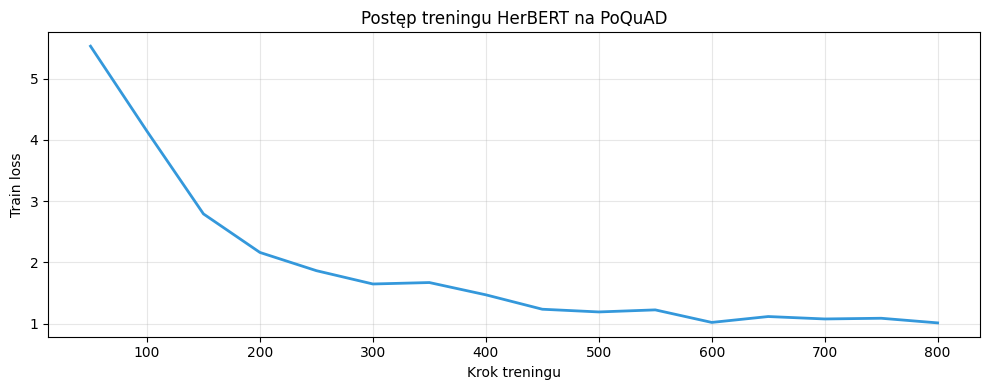

In [96]:
# Ekstrakcja historii z log_history
logs = trainer.state.log_history

train_losses = [(l['step'], l['loss']) for l in logs if 'loss' in l and 'eval_loss' not in l]

if train_losses:
    steps, losses = zip(*train_losses)
    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses, color='#3498db', linewidth=2)
    plt.xlabel('Krok treningu')
    plt.ylabel('Train loss')
    plt.title('Postęp treningu HerBERT na PoQuAD')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# 8. Ewaluacja na zbiorze walidacyjnym — post-processing logitów

Model zwraca dla każdego okna dwie listy logitów (początek, koniec). Żeby uzyskać tekstową odpowiedź, trzeba:

1. Dla każdego okna znaleźć pary `(start_idx, end_idx)` o najwyższej sumie logitów (z warunkami: `start <= end`, długość ≤ `max_answer_length`, oba w obrębie kontekstu).
2. Zebrać wszystkie okna należące do tego samego przykładu i wybrać **najlepszą globalnie** odpowiedź.
3. Zmapować tokeny z powrotem na znaki w kontekście przez `offset_mapping`.

Ten algorytm („n-best span extraction") to standard dla SQuAD.


In [97]:
def postprocess_qa_predictions(examples, features, raw_predictions,
                                n_best_size=20, max_answer_length=80):
    """Konwertuje logity modelu na tekstowe odpowiedzi."""
    all_start_logits, all_end_logits = raw_predictions

    # Mapowanie id_przykładu -> lista indeksów okien
    example_id_to_features = collections.defaultdict(list)
    for i, feature in enumerate(features):
        example_id_to_features[feature["example_id"]].append(i)

    predictions = collections.OrderedDict()

    for example in tqdm(examples, desc="Post-processing"):
        example_id = example["id"]
        context = example["context"]

        valid_answers = []

        for feature_index in example_id_to_features[example_id]:
            start_logits = all_start_logits[feature_index]
            end_logits   = all_end_logits[feature_index]
            offset_mapping = features[feature_index]["offset_mapping"]

            # Top-n indeksów dla start i end
            start_indexes = np.argsort(start_logits)[-1 : -n_best_size - 1 : -1].tolist()
            end_indexes   = np.argsort(end_logits)[-1 : -n_best_size - 1 : -1].tolist()

            for start_index in start_indexes:
                for end_index in end_indexes:
                    # Pomijamy pary spoza kontekstu
                    if (start_index >= len(offset_mapping)
                        or end_index >= len(offset_mapping)
                        or offset_mapping[start_index] is None
                        or offset_mapping[end_index] is None):
                        continue
                    # Pomijamy odpowiedzi z end < start lub za długie
                    if end_index < start_index or end_index - start_index + 1 > max_answer_length:
                        continue

                    start_char = offset_mapping[start_index][0]
                    end_char   = offset_mapping[end_index][1]
                    valid_answers.append({
                        "score": start_logits[start_index] + end_logits[end_index],
                        "text":  context[start_char:end_char],
                    })

        if valid_answers:
            best = sorted(valid_answers, key=lambda x: x["score"], reverse=True)[0]
            predictions[example_id] = best["text"]
        else:
            predictions[example_id] = ""

    return predictions


In [98]:
# Predykcja surowa (logity) — wyłączamy kolumny nieliczbowe przed predict()
predict_features = validation_features.remove_columns(["example_id", "offset_mapping"])
raw_predictions = trainer.predict(predict_features)

print(f"Kształt logitów (start): {raw_predictions.predictions[0].shape}")
print(f"Kształt logitów (end):   {raw_predictions.predictions[1].shape}")


Kształt logitów (start): (1076, 384)
Kształt logitów (end):   (1076, 384)


In [99]:
# Post-processing → tekstowe odpowiedzi
final_predictions = postprocess_qa_predictions(
    small_eval, validation_features, raw_predictions.predictions
)

# Złote odpowiedzi
references = {ex["id"]: ex["answers"]["text"] for ex in small_eval}

# Metryki
transformer_predictions = [final_predictions[ex["id"]] for ex in small_eval]
transformer_references  = [references[ex["id"]] for ex in small_eval]

transformer_scores = squad_metrics(transformer_predictions, transformer_references)
print("\nWyniki HerBERT na zbiorze walidacyjnym (podzbiór):")
print(f"  Exact Match: {transformer_scores['exact_match']:.2f}%")
print(f"  F1:          {transformer_scores['f1']:.2f}")
print(f"  N przykładów: {transformer_scores['n']}")


Post-processing:   0%|          | 0/1000 [00:00<?, ?it/s]


Wyniki HerBERT na zbiorze walidacyjnym (podzbiór):
  Exact Match: 52.70%
  F1:          73.78
  N przykładów: 1000


# 9. Porównanie klasyczny vs transformer

Pełne zestawienie. Oba modele były ewaluowane na **tym samym podzbiorze walidacyjnym** (1000 przykładów dla transformera, 500 dla klasycznego ze względu na koszt spaCy).


In [100]:
# Dla uczciwego porównania — przeliczmy klasyczny baseline na tym samym 1000-przykładowym zbiorze
classical_predictions_full = []
classical_references_full  = []
for ex in tqdm(small_eval, desc="Klasyczny baseline (pełny eval)"):
    pred, _ = classical_qa(ex['question'], ex['context'])
    classical_predictions_full.append(pred)
    classical_references_full.append(ex['answers']['text'])

classical_scores_full = squad_metrics(classical_predictions_full, classical_references_full)


Klasyczny baseline (pełny eval):   0%|          | 0/1000 [00:00<?, ?it/s]

In [101]:
# Zestawienie wyników
comparison = pd.DataFrame({
    'Model':       ['Klasyczny (TF-IDF + NER)', 'HerBERT fine-tuned'],
    'Exact Match': [classical_scores_full['exact_match'], transformer_scores['exact_match']],
    'F1':          [classical_scores_full['f1'],          transformer_scores['f1']],
    'N':           [classical_scores_full['n'],           transformer_scores['n']],
})

print(comparison.to_string(index=False))


                   Model  Exact Match        F1    N
Klasyczny (TF-IDF + NER)          4.1 21.116368 1000
      HerBERT fine-tuned         52.7 73.780821 1000


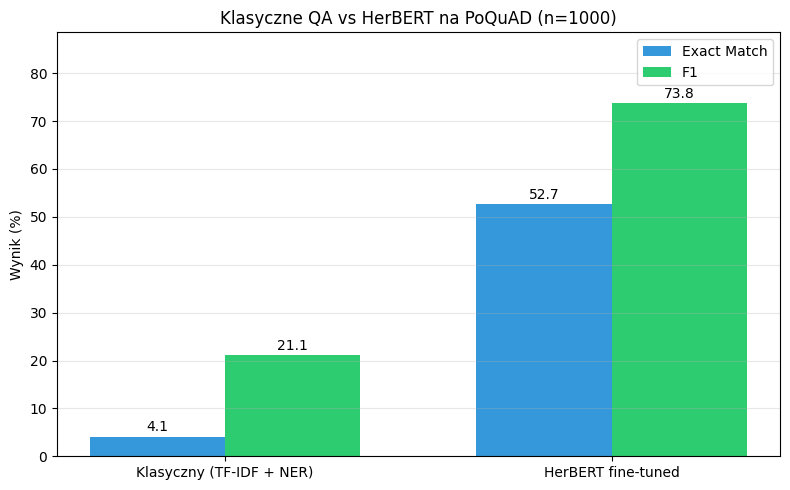

In [102]:
# Wizualizacja porównania
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison))
width = 0.35

b1 = ax.bar(x - width/2, comparison['Exact Match'], width, label='Exact Match', color='#3498db')
b2 = ax.bar(x + width/2, comparison['F1'],          width, label='F1',          color='#2ecc71')

for bars in [b1, b2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylabel('Wynik (%)')
ax.set_title('Klasyczne QA vs HerBERT na PoQuAD (n=1000)')
ax.legend()
ax.set_ylim(0, max(comparison['F1'].max(), comparison['Exact Match'].max()) * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 9.1. Interpretacja różnic

Oczekiwane obserwacje:

- **Transformer bije klasyczny baseline o duży margines** (typowo F1 ~70 vs ~25) mimo tego, że trenowaliśmy tylko na 6k przykładów i przez 2 epoki. Pełne trenowanie na 46k przykładów przez 3+ epok dałoby jeszcze lepsze wyniki (SOTA dla PoQuAD to F1 ~85).
- **EM rośnie proporcjonalnie bardziej niż F1** — transformer częściej trafia w **dokładnie tę samą frazę** co człowiek, podczas gdy klasyczny często zwraca cały fragment zdania.
- Klasyczny baseline łapie tylko najprostsze pytania faktograficzne („Kiedy?", „Kto?") — złożone pytania abstrakcyjne trafiają się transformerowi, a klasyczny zwraca wtedy przypadkowy fragment.


# 10. Predykcja na nowych tekstach — pipeline HF

Do wygodnego użytkowania wytrenowanego modelu używamy klasy `pipeline("question-answering")` z biblioteki transformers. Pod spodem wykonuje ona cały opisany wyżej post-processing.


In [103]:
qa_pipeline = pipeline(
    "question-answering",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

# Własne konteksty i pytania
custom_context_1 = """
Uniwersytet Warmińsko-Mazurski w Olsztynie (UWM) powstał 1 września 1999 roku
z połączenia Akademii Rolniczo-Technicznej, Wyższej Szkoły Pedagogicznej oraz
Warmińskiego Instytutu Teologicznego. Pierwszym rektorem uczelni został prof.
Ryszard Górecki. Główny kampus uczelni znajduje się w olsztyńskiej dzielnicy
Kortowo, nad jeziorem Kortowskim.
"""

questions_1 = [
    "Kiedy powstał UWM w Olsztynie?",
    "Kto był pierwszym rektorem uczelni?",
    "Gdzie znajduje się główny kampus?",
    "Z połączenia jakich szkół powstał UWM?",
]

print("=" * 70)
print("KONTEKST 1 — Uniwersytet Warmińsko-Mazurski")
print("=" * 70)
for q in questions_1:
    result = qa_pipeline(question=q, context=custom_context_1)
    print(f"\nP: {q}")
    print(f"O: {result['answer']}  (score={result['score']:.3f})")


KONTEKST 1 — Uniwersytet Warmińsko-Mazurski

P: Kiedy powstał UWM w Olsztynie?
O: 1 września 1999  (score=0.594)

P: Kto był pierwszym rektorem uczelni?
O: prof.
Ryszard Górecki  (score=0.551)

P: Gdzie znajduje się główny kampus?
O: w olsztyńskiej dzielnicy
Kortowo  (score=0.282)

P: Z połączenia jakich szkół powstał UWM?
O: Akademii Rolniczo-Technicznej, Wyższej Szkoły Pedagogicznej  (score=0.025)


In [104]:
custom_context_2 = """
Fryderyk Chopin urodził się 1 marca 1810 roku w Żelazowej Woli pod Warszawą.
Kompozytor i pianista, jeden z najwybitniejszych przedstawicieli muzyki
romantycznej. W 1830 roku wyjechał z Polski i osiadł w Paryżu, gdzie spędził
resztę życia. Zmarł 17 października 1849 roku na gruźlicę. Napisał m.in. dwa
koncerty fortepianowe, liczne mazurki, polonezy, nokturny i etiudy.
"""

questions_2 = [
    "Gdzie urodził się Chopin?",
    "Kiedy Chopin wyjechał z Polski?",
    "Na co zmarł Chopin?",
    "Ile koncertów fortepianowych napisał Chopin?",
]

print("=" * 70)
print("KONTEKST 2 — Fryderyk Chopin")
print("=" * 70)
for q in questions_2:
    result = qa_pipeline(question=q, context=custom_context_2)
    print(f"\nP: {q}")
    print(f"O: {result['answer']}  (score={result['score']:.3f})")


KONTEKST 2 — Fryderyk Chopin

P: Gdzie urodził się Chopin?
O: w Żelazowej Woli pod Warszawą  (score=0.502)

P: Kiedy Chopin wyjechał z Polski?
O: W 1830  (score=0.522)

P: Na co zmarł Chopin?
O: gruźlicę  (score=0.546)

P: Ile koncertów fortepianowych napisał Chopin?
O: dwa  (score=0.725)


# 11. Analiza błędów

Przyjrzyjmy się, na jakich pytaniach transformer zawodzi.


In [105]:
# DataFrame z predykcjami i prawdami
error_df = pd.DataFrame({
    'question':   [ex['question'] for ex in small_eval],
    'gold':       [ex['answers']['text'][0] if ex['answers']['text'] else '' for ex in small_eval],
    'predicted':  transformer_predictions,
    'context':    [ex['context'] for ex in small_eval],
})

# F1 i EM dla każdego przykładu
error_df['em'] = error_df.apply(lambda r: compute_exact(r['gold'], r['predicted']), axis=1)
error_df['f1'] = error_df.apply(lambda r: compute_f1(r['gold'], r['predicted']), axis=1)

print(f"Przykłady z EM = 1: {error_df['em'].sum()} / {len(error_df)} "
      f"({error_df['em'].mean()*100:.1f}%)")
print(f"Przykłady z F1 > 0 ale EM = 0: {((error_df['f1'] > 0) & (error_df['em'] == 0)).sum()} "
      f"(częściowe trafienie)")
print(f"Przykłady z F1 = 0: {(error_df['f1'] == 0).sum()} (całkowity miss)")


Przykłady z EM = 1: 527 / 1000 (52.7%)
Przykłady z F1 > 0 ale EM = 0: 372 (częściowe trafienie)
Przykłady z F1 = 0: 101 (całkowity miss)


In [106]:
# 5 losowych przykładów gdzie model się pomylił całkowicie
misses = error_df[error_df['f1'] == 0].sample(min(5, (error_df['f1'] == 0).sum()), random_state=SEED)

print("Przykłady całkowitych missów:")
print("=" * 80)
for _, row in misses.iterrows():
    print(f"P: {row['question']}")
    print(f"ZŁOTA:     {row['gold']}")
    print(f"PREDYKCJA: {row['predicted']}")
    print("-" * 80)


Przykłady całkowitych missów:
P: Dlaczego Roosevelt rozpoczął działania, które miały prowadzić do zmiany ustawy o neutralności?
ZŁOTA:     stwierdził, że tak sformułowane prawo może stanowić zachętę dla agresora
PREDYKCJA: Widząc narastające zagrożenie ze strony Hitlera
--------------------------------------------------------------------------------
P: W którym roku zginął Oscar Romero?
ZŁOTA:     1980
PREDYKCJA: marcu tego
--------------------------------------------------------------------------------
P: Czy gnębienie chrześcijan dobiegło obecnie końca?
ZŁOTA:     Współcześnie w wielu krajach świata dochodzi do prześladowań chrześcijan z powodu wyznawanej przez nich wiary
PREDYKCJA: obecnie chrześcijaństwo jest najbardziej prześladowaną religią na świecie
--------------------------------------------------------------------------------
P: Kto założył NUP?
ZŁOTA:     Armia
PREDYKCJA: Aung San Suu Kyi
--------------------------------------------------------------------------------
P: Z 

In [107]:
# 5 przykładów z częściowym trafieniem (F1 między 0 a 1)
partial = error_df[(error_df['f1'] > 0) & (error_df['em'] == 0)].sample(
    min(5, ((error_df['f1'] > 0) & (error_df['em'] == 0)).sum()), random_state=SEED
)

print("Przykłady częściowych trafień:")
print("=" * 80)
for _, row in partial.iterrows():
    print(f"P: {row['question']}")
    print(f"ZŁOTA:     {row['gold']}")
    print(f"PREDYKCJA: {row['predicted']}  (F1={row['f1']:.2f})")
    print("-" * 80)


Przykłady częściowych trafień:
P: Jakie funkcje pełnił w zespole Bajm Jarosław Kozidrak od 1982 roku?
ZŁOTA:     nie tylko grał na gitarze i udzielał się wokalnie, ale występował także na instrumentach klawiszowych
PREDYKCJA: gitarzystą zespołu został Henryk Mazurek, a basistą – Marek Makuch, natomiast Jarosław Kozidrak już nie tylko grał na gitarze i udzielał się wokalnie, ale występował także na instrumentach klawiszowych  (F1=0.70)
--------------------------------------------------------------------------------
P: Czy tiki wokalne są stałe i zawsze występują w jednakowej formie?
ZŁOTA:     Tiki wokalne pojawiają się i zanikają przyjmując różne formy
PREDYKCJA: pojawiają się i zanikają przyjmując różne formy  (F1=0.88)
--------------------------------------------------------------------------------
P: Czy Carrà kiedykolwiek wystąpiła w komedii?
ZŁOTA:     występując w takich filmach jak: komedia 5 marines per 100 ragazze
PREDYKCJA: Kontynuowała karierę, występując w takich filmach ja

# 12. Zapis modelu

Zachowujemy wytrenowany model lokalnie. Można go potem załadować przez `from_pretrained(sciezka)` lub opublikować na Hugging Face Hub.


In [108]:
# Zapis lokalny
MODEL_DIR = "./herbert-poquad-finetuned"
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

import os
total_size_mb = sum(
    os.path.getsize(os.path.join(MODEL_DIR, f))
    for f in os.listdir(MODEL_DIR)
    if os.path.isfile(os.path.join(MODEL_DIR, f))
) / 1e6
print(f"Model zapisany w: {MODEL_DIR}")
print(f"Łączny rozmiar: {total_size_mb:.1f} MB")
print("Zawartość:")
for f in sorted(os.listdir(MODEL_DIR)):
    size_mb = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1e6
    print(f"  {f:30s} {size_mb:>7.2f} MB")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model zapisany w: ./herbert-poquad-finetuned
Łączny rozmiar: 499.1 MB
Zawartość:
  config.json                       0.00 MB
  model.safetensors               495.44 MB
  tokenizer.json                    3.69 MB
  tokenizer_config.json             0.00 MB
  training_args.bin                 0.01 MB


In [109]:
# Ładowanie zapisanego modelu i szybki test (tak jakbyśmy uruchomili notatnik od nowa)
from transformers import pipeline as hf_pipeline

loaded_qa = hf_pipeline(
    "question-answering",
    model=MODEL_DIR,
    tokenizer=MODEL_DIR,
    device=0 if torch.cuda.is_available() else -1,
)

test_context = """
Jezioro Śniardwy o powierzchni 113,8 km² jest największym jeziorem w Polsce.
Znajduje się na Pojezierzu Mazurskim w województwie warmińsko-mazurskim.
Średnia głębokość jeziora wynosi 5,9 metra, a maksymalna 23,4 metra.
"""

for q in ["Jakie jest największe jezioro w Polsce?",
          "Jaka jest powierzchnia Śniardw?",
          "Gdzie leży jezioro Śniardwy?"]:
    ans = loaded_qa(question=q, context=test_context)
    print(f"P: {q}")
    print(f"O: {ans['answer']}  (score={ans['score']:.3f})")
    print()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

P: Jakie jest największe jezioro w Polsce?
O: Śniardwy  (score=0.524)

P: Jaka jest powierzchnia Śniardw?
O: 113,8 km²  (score=0.862)

P: Gdzie leży jezioro Śniardwy?
O: na Pojezierzu Mazurskim  (score=0.326)



# Ćwiczenia

## Ćwiczenie A: QA nad artykułem Wikipedii o Olsztynie

Wykorzystaj kod niżej na pytania o **Olsztyn** (a potem własne trzy tematy) na podstawie artykułu z polskiej Wikipedii.

**Kroki:**

1. Pobierz treść artykułu [Olsztyn](https://pl.wikipedia.org/wiki/Olsztyn) przez bibliotekę `wikipedia` (lub bezpośrednio przez API MediaWiki).
2. Podziel tekst na fragmenty funkcją `chunk_text`.
3. Zbuduj retriever TF-IDF (jak wyżej) na tych fragmentach.
4. Zadaj modelowi kilka pytań o Olsztyn i sprawdź, czy odpowiedzi są sensowne.

**Przykładowe pytania:**

- Ile mieszkańców ma Olsztyn?
- W którym województwie leży Olsztyn?
- Nad jakim jeziorem leży Olsztyn?
- Kiedy lokowano miasto Olsztyn?
- Jaka rzeka przepływa przez Olsztyn?
- Jaka jest powierzchnia Olsztyna?

**Pytania dodatkowe (trudniejsze):** Spróbuj zadać pytania wymagające syntezy kilku faktów — np. *"Jakie uczelnie wyższe znajdują się w Olsztynie?"*, *"Jakie są największe zakłady przemysłowe w mieście?"*. Zwróć uwagę, czy model potrafi zwrócić listę, czy tylko pojedynczy element — to ograniczenie podejścia *extractive*.

In [120]:
# ============================================================
# Ćwiczenie D — QA nad artykułem Wikipedii o Olsztynie
# ============================================================

# 1. Instalacja biblioteki wikipedia (jeśli brakuje)
!pip install -q wikipedia

import wikipedia
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

wikipedia.set_lang("pl")

# ------------------------------------------------------------
# 2. Pobranie artykułu o Olsztynie
# ------------------------------------------------------------
page = wikipedia.page("Olsztyn", auto_suggest=False)
article_text = page.content

print(f"Tytuł: {page.title}")
print(f"URL:   {page.url}")
print(f"Długość artykułu: {len(article_text):,} znaków")
print(f"\nPoczątek artykułu:\n{article_text[:400]}...")

# ------------------------------------------------------------
# 3. Funkcja chunk_text — dzielenie na fragmenty z nakładką
# ------------------------------------------------------------
def chunk_text(text, chunk_size=1000, overlap=150):
    """
    Dzieli długi tekst na fragmenty o zadanej długości znaków
    z nakładką, starając się nie łamać zdań.
    """
    # Usuń nagłówki sekcji w stylu "== Historia ==" — zastąp je kropką
    text = re.sub(r'=+\s*[^=\n]+\s*=+', '.', text)
    text = re.sub(r'\s+', ' ', text).strip()

    chunks = []
    start = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        # Spróbuj znaleźć koniec zdania w okolicy `end`
        if end < len(text):
            last_dot = text.rfind('.', start + chunk_size // 2, end)
            if last_dot != -1:
                end = last_dot + 1
        chunks.append(text[start:end].strip())
        if end >= len(text):
            break
        start = end - overlap
    return [c for c in chunks if len(c) > 50]


chunks = chunk_text(article_text, chunk_size=2000, overlap=300)
print(f"\nLiczba fragmentów: {len(chunks)}")
print(f"Średnia długość fragmentu: {np.mean([len(c) for c in chunks]):.0f} znaków")
print(f"\nPrzykładowy fragment [0]:\n{chunks[0][:300]}...")

# ------------------------------------------------------------
# 4. Retriever TF-IDF nad fragmentami
# ------------------------------------------------------------
retriever_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
chunk_matrix = retriever_vectorizer.fit_transform(chunks)


def retrieve_top_k(question, k=3):
    """Zwraca k najbardziej pasujących fragmentów do pytania."""
    q_vec = retriever_vectorizer.transform([question])
    sims = cosine_similarity(q_vec, chunk_matrix).flatten()
    top_idx = np.argsort(sims)[::-1][:k]
    return [(chunks[i], float(sims[i])) for i in top_idx]


# ------------------------------------------------------------
# 5. Pipeline retrieval + reader (HerBERT)
# ------------------------------------------------------------
def answer_question(question, k=3, verbose=False):
    """
    1) Retriever TF-IDF zwraca top-k fragmentów.
    2) Reader (HerBERT) liczy odpowiedź dla każdego.
    3) Zwracamy odpowiedź o najwyższym score.
    """
    top_chunks = retrieve_top_k(question, k=k)
    best = {"answer": "", "score": -1, "context": ""}
    for ctx, sim in top_chunks:
        try:
            res = qa_pipeline(question=question, context=ctx)
            if res["score"] > best["score"]:
                best = {"answer": res["answer"], "score": res["score"], "context": ctx}
        except Exception as e:
            if verbose:
                print(f"  [warn] {e}")
    return best


# ------------------------------------------------------------
# 6. Test — przykładowe pytania o Olsztyn
# ------------------------------------------------------------
questions = [
    "Ile mieszkańców ma Olsztyn?",
    "W którym województwie leży Olsztyn?",
    "Nad jakim jeziorem leży Olsztyn?",
    "Kiedy lokowano miasto Olsztyn?",
    "Jaka rzeka przepływa przez Olsztyn?",
    "Jaka jest powierzchnia Olsztyna?",
    # Trudniejsze — wymagające syntezy / listy
    "Jakie uczelnie wyższe znajdują się w Olsztynie?",
    "Jakie są największe zakłady przemysłowe w mieście?",
]

print("=" * 75)
print("QA nad artykułem Wikipedii o Olsztynie")
print("=" * 75)
for q in questions:
    result = answer_question(q, k=3)
    print(f"\nP: {q}")
    print(f"O: {result['answer']}  (score={result['score']:.3f})")


Tytuł: Olsztyn
URL:   https://pl.wikipedia.org/wiki/Olsztyn
Długość artykułu: 77,465 znaków

Początek artykułu:
Olsztyn (dawn. niem. Allenstein, łac. Allenstenium, Holstin) – miasto na prawach powiatu, stolica województwa warmińsko-mazurskiego, siedziba władz ziemskiego powiatu olsztyńskiego, kurii archidiecezji warmińskiej i greckokatolickiej eparchii olsztyńsko-gdańskiej. Główny ośrodek gospodarczy, edukacyjny i kulturowy, siedziba władz i instytucji regionu, a także węzeł kolejowy i drogowy. Miasto centr...

Liczba fragmentów: 47
Średnia długość fragmentu: 1903 znaków

Przykładowy fragment [0]:
Olsztyn (dawn. niem. Allenstein, łac. Allenstenium, Holstin) – miasto na prawach powiatu, stolica województwa warmińsko-mazurskiego, siedziba władz ziemskiego powiatu olsztyńskiego, kurii archidiecezji warmińskiej i greckokatolickiej eparchii olsztyńsko-gdańskiej. Główny ośrodek gospodarczy, edukacy...
QA nad artykułem Wikipedii o Olsztynie

P: Ile mieszkańców ma Olsztyn?
O: 5863  (score=0.00

In [121]:
from transformers import pipeline as hf_pipeline

loaded_qa = hf_pipeline(
    "question-answering",
    model=MODEL_DIR,
    tokenizer=MODEL_DIR,
    device=0 if torch.cuda.is_available() else -1,
)



for q in questions:
    ans = loaded_qa(question=q, context=article_text)
    print(f"P: {q}")
    print(f"O: {ans['answer']}  (score={ans['score']:.3f})")
    print()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

P: Ile mieszkańców ma Olsztyn?
O: 166 392  (score=0.906)

P: W którym województwie leży Olsztyn?
O: warmińsko-mazurskiego  (score=1.128)

P: Nad jakim jeziorem leży Olsztyn?
O: Łyną  (score=1.015)

P: Kiedy lokowano miasto Olsztyn?
O: 1353–2003  (score=0.480)

P: Jaka rzeka przepływa przez Olsztyn?
O: Łyna, Wadąg, Kortówka i Skanda  (score=1.412)

P: Jaka jest powierzchnia Olsztyna?
O: 88,33 km²  (score=0.780)

P: Jakie uczelnie wyższe znajdują się w Olsztynie?
O: Uniwersytet Warmińsko-Mazurski  (score=0.246)

P: Jakie są największe zakłady przemysłowe w mieście?
O: Michelin  (score=0.115)



In [111]:
# Miejsce na własny artykuł i pytania (I)
#
#

In [112]:
# Miejsce na własny artykuł i pytania (II)
#
#

In [113]:
# Miejsce na własny artykuł i pytania (III)
#
#



## Ćwiczenie B: pełny fine-tuning i porównanie z tym z notatnika

Powtórz fine-tuning na **pełnym zbiorze treningowym** (46k przykładów) i 3 epokach. Porównaj EM/F1 z wynikami z niniejszego notatnika. O ile poprawia się wynik względem uczenia na podzbiorze?

**Uwaga:** Pełny trening zajmie ok. 45–60 minut na T4. Na Colabie darmowym może zostać przerwany — rozważ użycie checkpointów (`save_strategy="epoch"`) i wznowienie treningu w razie przerwania.


In [114]:
# Ćwiczenie A — szkielet
# training_args_full = TrainingArguments(
#     output_dir="./herbert-poquad-full",
#     num_train_epochs=3,
#     ...
# )
#
# train_features_full = raw_datasets["train"].map(prepare_train_features, batched=True,
#                                                  remove_columns=raw_datasets["train"].column_names)
# ...
